In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data = pd.read_csv('/content/ai_assistant_usage_student_life.csv')
df = pd.DataFrame(data)

In [ ]:
df.size

150000

In [ ]:
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [ ]:
df.sample(10)

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
4768,SESSION04769,Undergraduate,History,2024-11-15,13.34,4,Homework Help,2,Assignment Completed,True,1.0
4070,SESSION04071,Undergraduate,Psychology,2024-12-26,6.99,1,Writing,4,Idea Drafted,False,4.2
1615,SESSION01616,Undergraduate,Business,2025-04-16,6.73,2,Coding,3,Idea Drafted,True,2.8
6499,SESSION06500,Undergraduate,Math,2024-08-30,21.99,4,Homework Help,4,Idea Drafted,True,4.4
3895,SESSION03896,Undergraduate,Computer Science,2024-07-18,24.86,8,Studying,1,Assignment Completed,True,1.0
5568,SESSION05569,Undergraduate,History,2024-09-03,25.41,5,Homework Help,4,Idea Drafted,True,3.1
9017,SESSION09018,Undergraduate,Psychology,2024-07-28,70.51,24,Homework Help,3,Confused,False,2.5
9397,SESSION09398,Undergraduate,Engineering,2024-08-12,21.13,4,Writing,2,Assignment Completed,True,3.0
6458,SESSION06459,High School,Psychology,2024-07-04,14.53,3,Writing,3,Idea Drafted,True,3.2
4461,SESSION04462,Undergraduate,Math,2024-08-19,15.56,3,Writing,5,Idea Drafted,False,4.5


## Detect Missing Values

In [ ]:
df.isnull().sum()

,0
SessionID,0
StudentLevel,0
Discipline,0
SessionDate,0
SessionLengthMin,0
TotalPrompts,0
TaskType,0
AI_AssistanceLevel,0
FinalOutcome,0
UsedAgain,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


## 1. Which student level uses AI assistants the most: Undergraduate, Graduate, or High School?

<Axes: xlabel='count', ylabel='StudentLevel'>

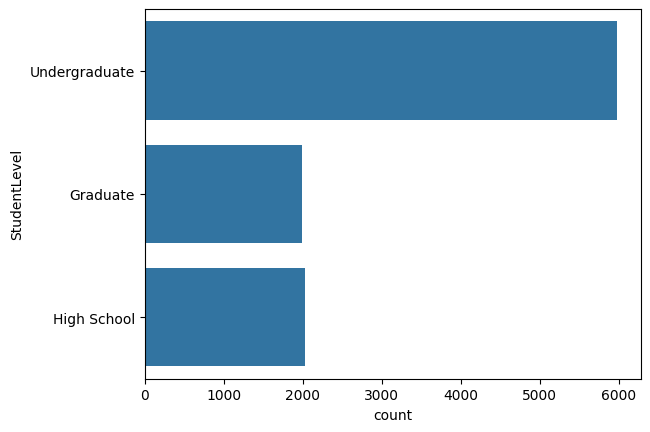

In [ ]:
sns.countplot(df['StudentLevel'])

### In this dataset undergraduates are more in count who uses AI assistants.

# 2. How different fields of  students we have in our dataset

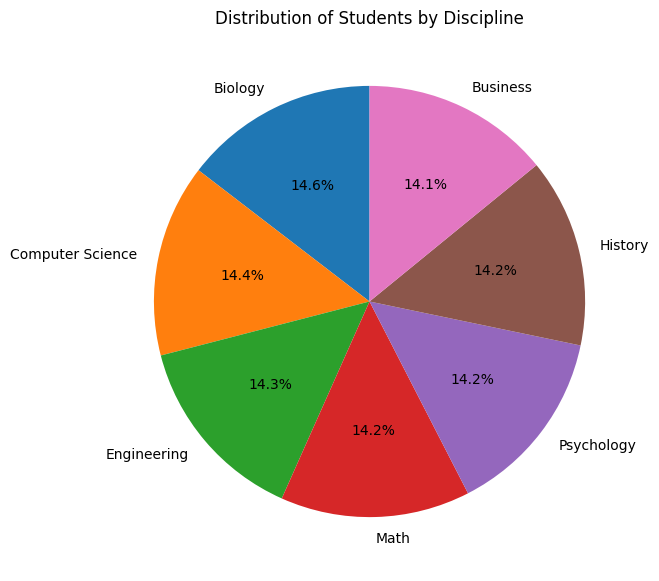

In [ ]:
discipline_counts = df['Discipline'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    discipline_counts,
    labels=discipline_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Students by Discipline")
plt.show()

In [ ]:
df['Discipline'].value_counts()

,count
Discipline,
Biology,1458
Computer Science,1445
Engineering,1430
Math,1422
Psychology,1418
History,1417
Business,1410


# 3. Students from which field use AI assistants more?

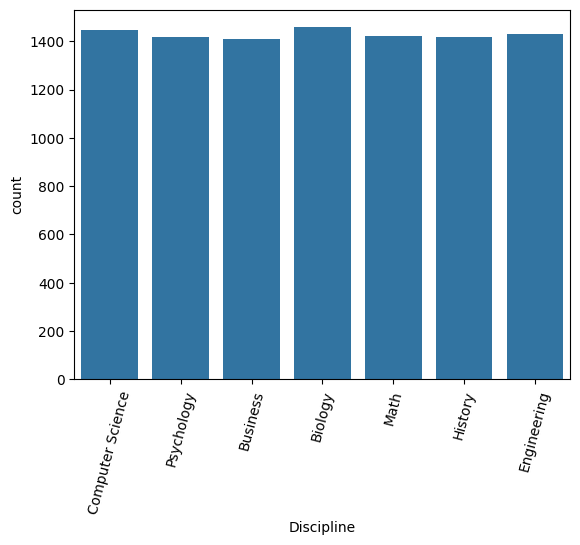

In [ ]:
sns.countplot(data=df,x='Discipline')
plt.xticks(rotation=75)
plt.show()

## 4. In Which task students mostly take help from AI assistants and which level of ai assistant helps them more to complete their tasks.?

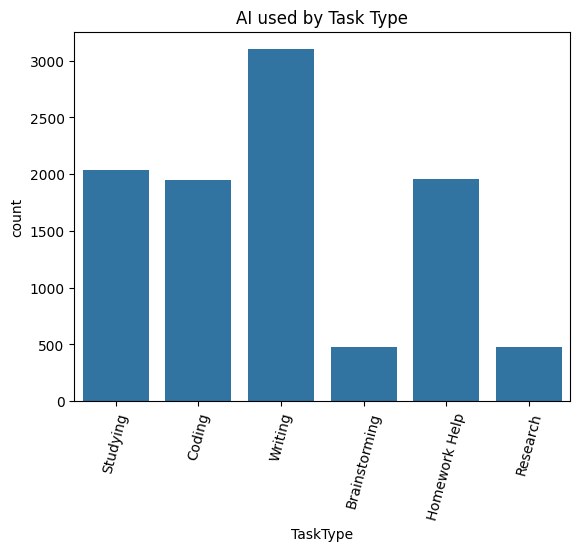

In [ ]:
# In which task students mostly use AI
sns.countplot(data=df,x='TaskType')
plt.title('AI used by Task Type')
plt.xticks(rotation=75)
plt.show()

### Mostly for writing purpose students use AI Assistant

Text(0.5, 1.0, 'Average Satisfaction level by AI assistant level')

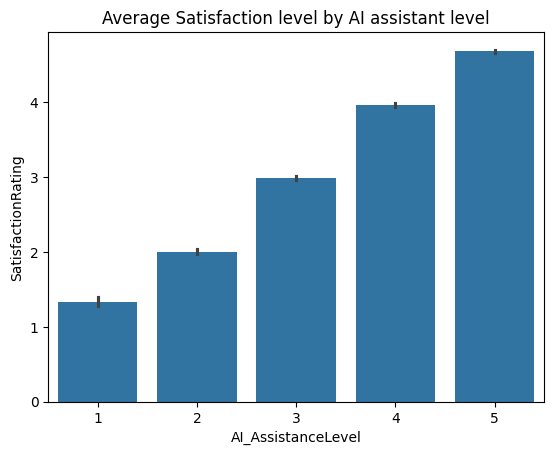

In [ ]:
# Which AI assistance level helps more?
sns.barplot(data=df,x='AI_AssistanceLevel',y='SatisfactionRating')
plt.title('Average Satisfaction level by AI assistant level')

# 5. How AI assistant level matters in Final outcome

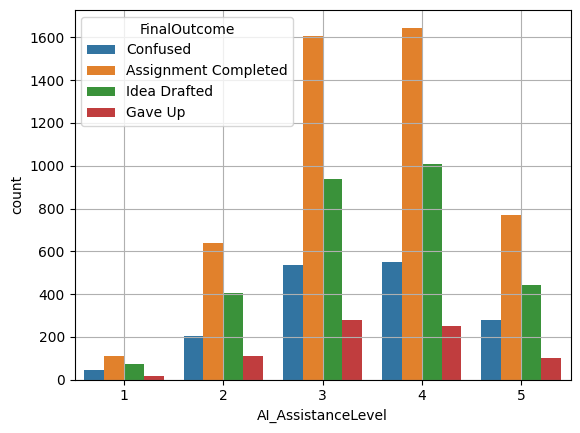

In [ ]:
sns.countplot(data=df,x='AI_AssistanceLevel', hue='FinalOutcome')
plt.grid(True)

### Although the ai assistance level 4 is highly used in assigment completion but if we are talking about quality of final outcome generated by assistant level then ai assistant level 3 is more better that ai assistant level 4. Because there is less cases of confused and gave up.

# 6. What session length is sufficient to accomplish different academic tasks using AI assistants?

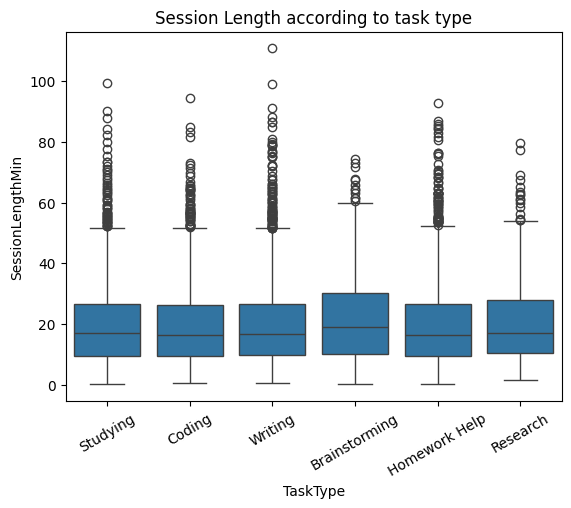

In [ ]:
sns.boxplot(data=df, x='TaskType', y='SessionLengthMin')
plt.xticks(rotation=30)
plt.title('Session Length according to task type')
plt.show()

### In case of Studying task students spent average time is around 18 minutes and maximum session goes around 99 minutes
### In case of coding average session length is around 17 minutes and maximum session length is around 95.
### In case of Writing task students spent average time 18 minutes and maximum time is more than 100 minutes.
### For Research average session lengths are around 15 and maximum session length are 80 minutes.
### According to this analysis Researchers might use AI assistant level 5 than others.


# 7. How much total prompts are required to complete task according to AI assistant level

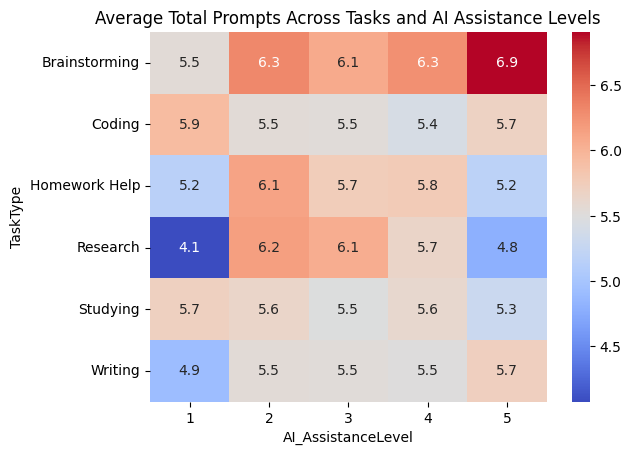

In [ ]:
pivot_table = df.pivot_table(
    values='TotalPrompts',
    index='TaskType', # y-axis
    columns='AI_AssistanceLevel', # x-axis
    aggfunc='mean' # average count of total prompts
)

sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Average Total Prompts Across Tasks and AI Assistance Levels")
plt.show()



### Numbers inside cells are total prompts
### Brainstorming task is more demanding.
### Different tasks use different AI tools,and higher level assistant level doest not mean fewer prompts.
### This heatmap shows how many prompts students use for different tasks at different AI assistance levels.
### For brainstorming and writing, students use more prompts when the AI level is higher because they explore more ideas.
### For research tasks, higher AI levels reduce the number of prompts, which means students get useful answers faster.
### Coding and studying tasks show almost the same number of prompts at all AI levels, so AI level does not make much difference there. Overall, the impact of AI assistance level depends on the type of task.

# Time Series Analysis

In [ ]:
df['SessionDate'] = pd.to_datetime(df['SessionDate'])
df['Year'] = df['SessionDate'].dt.year
df['Month'] = df['SessionDate'].dt.month
df['MonthName'] = df['SessionDate'].dt.month_name()
df['YearMonth'] = df['SessionDate'].dt.to_period('M')
df[['SessionDate', 'Year', 'Month', 'MonthName','YearMonth']].head()

,SessionDate,Year,Month,MonthName,YearMonth
0,2024-11-03,2024,11,November,2024-11
1,2024-08-25,2024,8,August,2024-08
2,2025-01-12,2025,1,January,2025-01
3,2025-05-06,2025,5,May,2025-05
4,2025-03-18,2025,3,March,2025-03


# 8. AI usage monthly

In [ ]:
monthly_usage = df.groupby('YearMonth').size().reset_index(name='UsageCount')

monthly_usage['YearMonth'] = monthly_usage['YearMonth'].dt.to_timestamp()



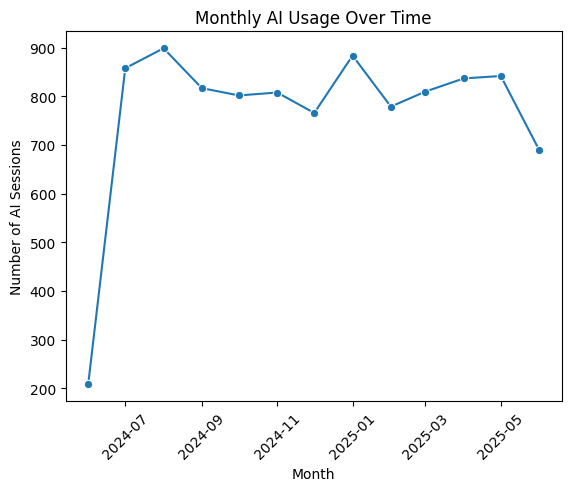

In [ ]:
sns.lineplot(
    data=monthly_usage,
    x='YearMonth',
    y='UsageCount',

    marker='o'
)

plt.title("Monthly AI Usage Over Time")
plt.xlabel("Month")
plt.ylabel("Number of AI Sessions")
plt.xticks(rotation=45)
plt.show()


### In this line plot we can see mid 2024 and early 2025 ai usage was on top then gradually after mid 2025 line lower may be exams were over in 2025 May.

# 9. Relationship between Student Education and  Course of students.

<Axes: xlabel='StudentLevel', ylabel='Discipline'>

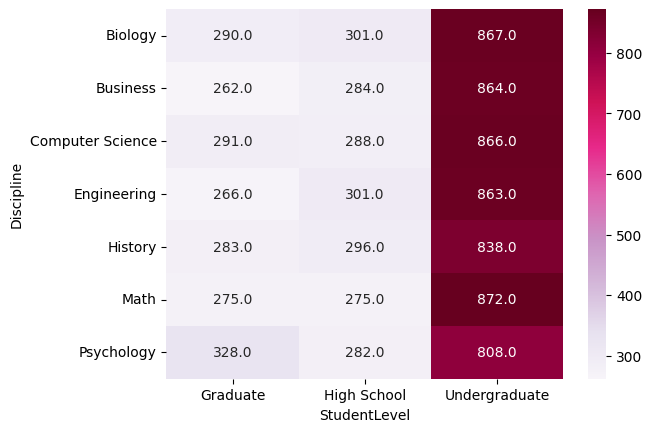

In [ ]:
sns.heatmap(pd.crosstab(df['Discipline'],df['StudentLevel']),cmap='PuRd',annot=True,fmt='.1f')

### In order to this heatmap Undergraduates from all courses except History and Psychology students Use AI assistants for their work.
### High level and Graduates are very less in count in this dataset

# 10. Distribution of Students reusing AI assistant

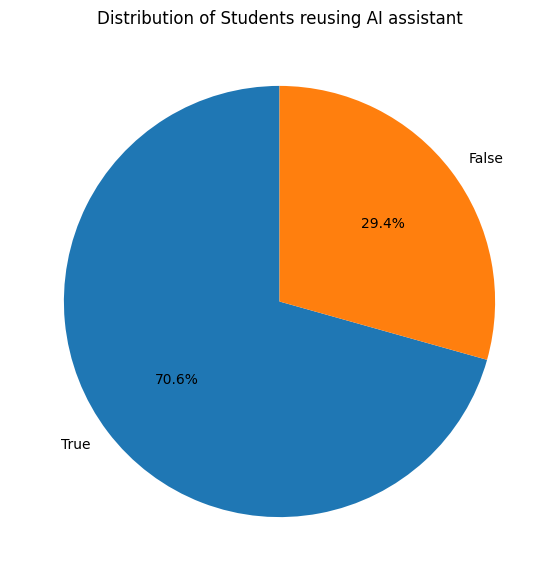

In [ ]:
UsedAgain = df['UsedAgain'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    UsedAgain,
    labels=UsedAgain.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Students reusing AI assistant")
plt.show()

### From here i can say Students was reused AI assistant for their another tasks

# 11. Students after finishing their task does they use same AI assistant again or not?

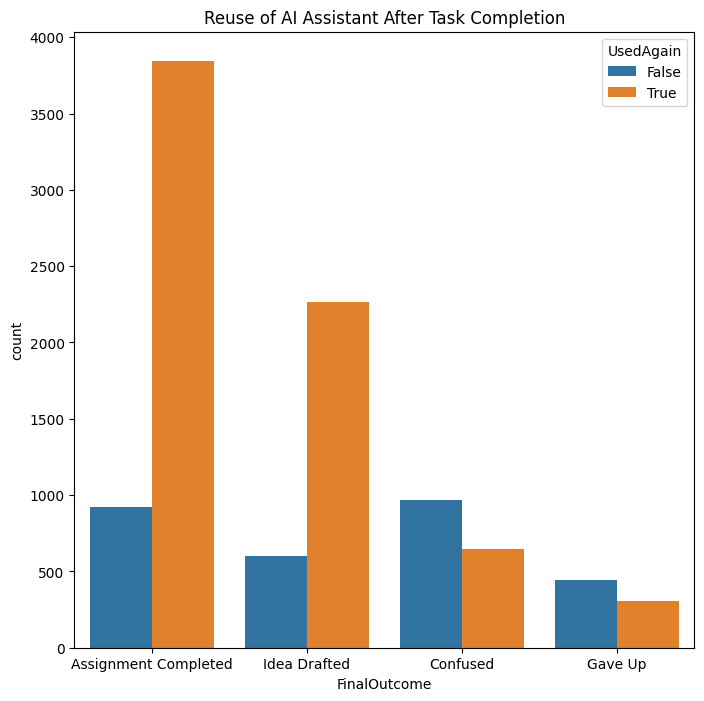

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(data=df, x='FinalOutcome', hue='UsedAgain')

plt.title("Reuse of AI Assistant After Task Completion")
plt.xticks(rotation=0)
plt.show()


# 12. Session Length vs Satisfaction

<Axes: xlabel='SessionLengthMin', ylabel='SatisfactionRating'>

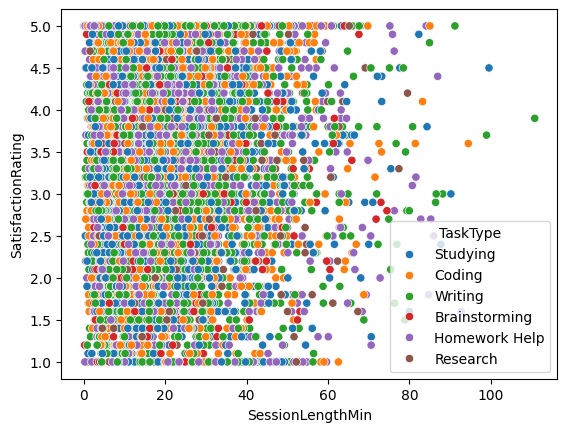

In [ ]:
sns.scatterplot(
    data=df,
    x='SessionLengthMin',
    y='SatisfactionRating',
    hue='TaskType',
)


# 13. How Year by year ai assistants improved by satisfaction ratings of students

In [ ]:
df.groupby('Year')['SatisfactionRating'].mean()
pivot = df.pivot_table(
    values='SatisfactionRating',
    index='Year',
    columns='AI_AssistanceLevel',
    aggfunc='mean'
)
pivot


AI_AssistanceLevel,1,2,3,4,5
Year,,,,,
2024,1.400862,1.994669,2.974108,3.948625,4.671528
2025,1.271200,2.004683,3.005730,3.968035,4.679092


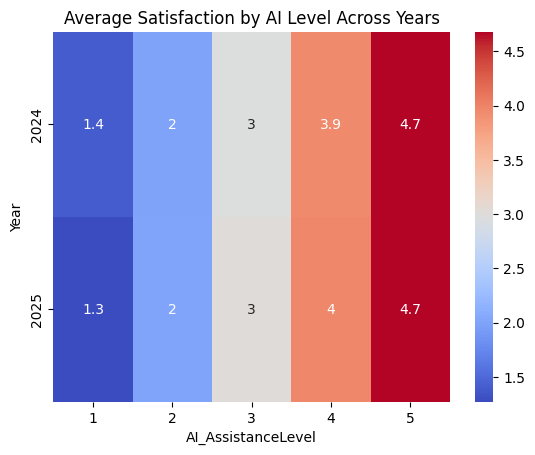

In [ ]:
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Average Satisfaction by AI Level Across Years")
plt.show()


### Ai assistant level 1 performance is decreased by 0.1.
### AI assistant level 2, 3 and 5 remain same in both years.
### AI assistant level 4 is improved by .1 in a year

# 14. Distribution of session length

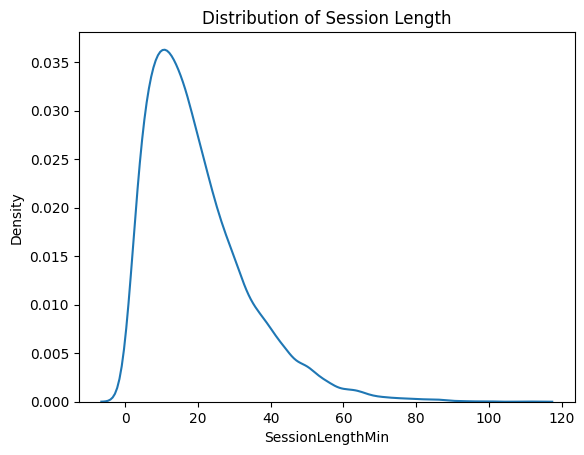

In [ ]:
sns.kdeplot(data=df, x='SessionLengthMin')
plt.title("Distribution of Session Length")
plt.show()


### Mostly sessions lengths are between AI assistant and Student is 1 to 55 minutes.

# 15. Distribution of SatisfactionRating

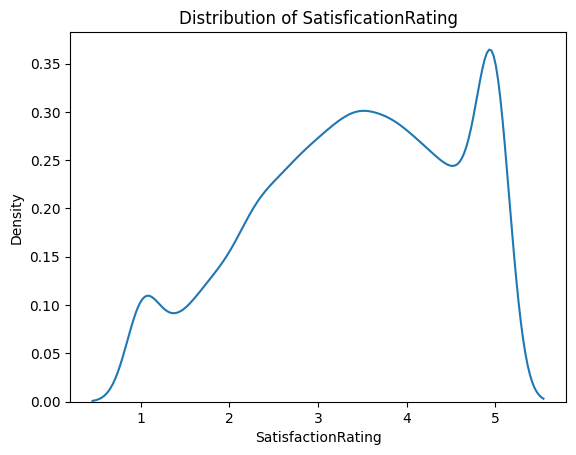

In [ ]:
sns.kdeplot(data=df, x='SatisfactionRating')
plt.title("Distribution of SatisficationRating")
plt.show()

### Most students rate high satisfaction with AI assistants, while a few students rate moderate satisfaction. Low satisfaction ratings are less, overall positive user experience.

## UsedAgain vs TaskType

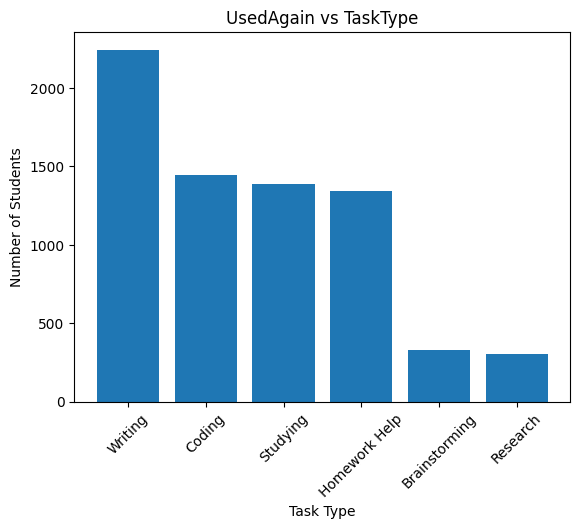

In [ ]:


used_again = df[df['UsedAgain'] == True]['TaskType'].value_counts()

plt.bar(used_again.index, used_again.values)
plt.xlabel('Task Type')
plt.ylabel('Number of Students')
plt.title('UsedAgain vs TaskType')
plt.xticks(rotation=45)
plt.show()


# UsedAgain vs StudentLevel

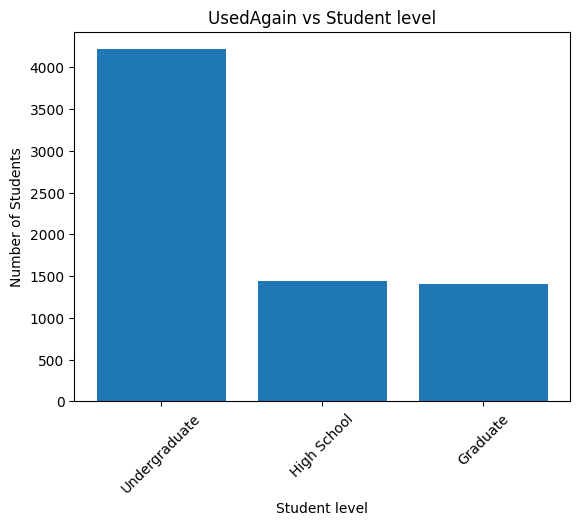

In [ ]:

used_again = df[df['UsedAgain'] == True]['StudentLevel'].value_counts()

plt.bar(used_again.index, used_again.values)
plt.xlabel('Student level')
plt.ylabel('Number of Students')
plt.title('UsedAgain vs Student level')
plt.xticks(rotation=45)
plt.show()

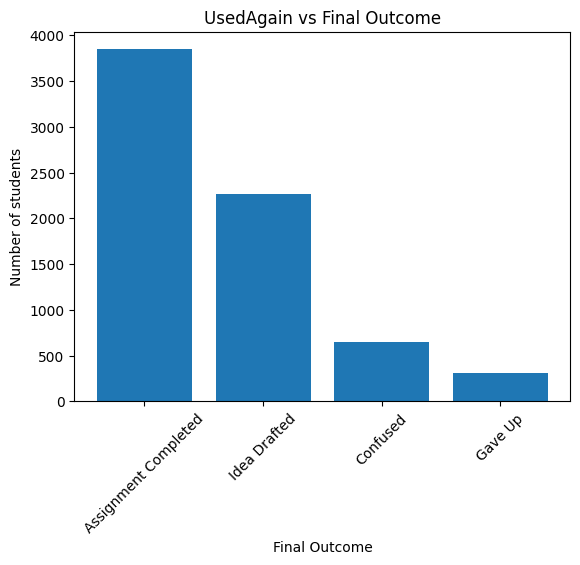

In [ ]:

used_again = df[df['UsedAgain'] == True]['FinalOutcome'].value_counts()

plt.bar(used_again.index, used_again.values)
plt.xlabel('Final Outcome')
plt.ylabel('Number of students')
plt.title('UsedAgain vs Final Outcome')
plt.xticks(rotation=45)
plt.show()